# Modeling, Evaluation and Interpretation

Forecasting `Global_active_power` (kWh/hour). Models: three naive baselines, SARIMA, LSTM and XGBoost (next-hour tuned, plus a direct next-day h=24). Evaluation follows the chronological split (train 2006-2009, test Jan-Nov 2010) with MAE as the primary metric and MASE scaled by the lag-24 seasonal naive.

In [1]:
from __future__ import annotations
import sys
from pathlib import Path
import pandas as pd
from IPython.display import Image
sys.path.insert(0, str(Path.cwd().parent))
from src import evaluation, metrics, modeling, stats_tests
ROOT = Path.cwd().parent
FIG = ROOT / 'reports' / 'figures' / 'modeling'
pd.set_option('display.width', 140)

In [2]:
df = pd.read_parquet(ROOT / 'data/processed/household_power_hourly_features.parquet')
matrix = modeling.build_model_matrix(df, verbose=False)
scale = metrics.seasonal_naive_scale(matrix.y_train.to_numpy())
preds = evaluation.load_predictions()
print('MASE seasonal-naive scale:', round(scale, 4))

MASE seasonal-naive scale: 0.6551


## Phase 14 - Test leaderboard (labelled by horizon)

In [3]:
evaluation.metrics_table(preds, scale).round(4)

,horizon,mae,rmse,mape,smape,mase
xgboost_tuned,h=1,0.333804,0.482307,41.923767,33.307492,0.509518
xgboost,h=1,0.334483,0.482939,41.841969,33.315982,0.510554
sarima,h=1,0.35941,0.5087,46.978588,36.218194,0.548603
lstm,h=1,0.371183,0.519691,49.336511,37.620296,0.566574
naive_lag1,h=1,0.395311,0.610051,44.035341,36.56928,0.603403
naive_lag24,h=1,0.551883,0.813907,68.156328,49.452883,0.842394
naive_lag168,h=1,0.58409,0.834294,75.710195,54.042942,0.891554
xgboost_h24,h=24,0.44444,0.606883,61.239068,44.271932,0.678393


## Phase 14 - Representative week and residual diagnostics

Week of 2010-02-08: the highest-demand full week in the test set (peak winter heating, high variance), where the models are most stressed.

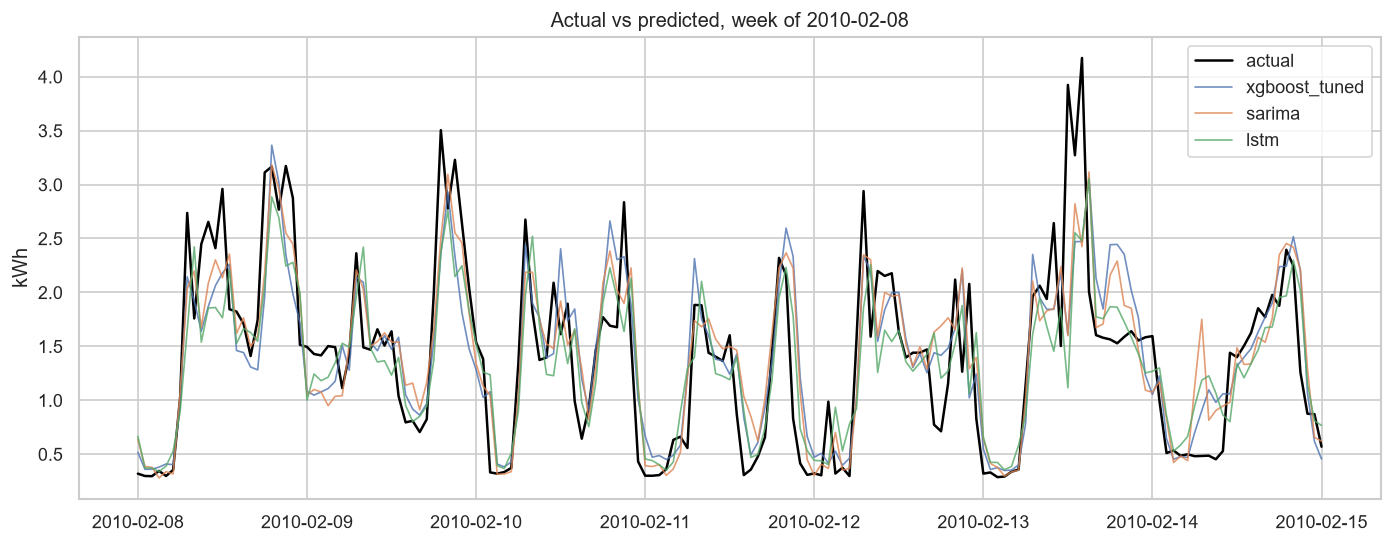

In [4]:
evaluation.plot_actual_vs_pred_week(preds, ['xgboost_tuned','sarima','lstm'], '2010-02-08')
Image(str(FIG / '01_actual_vs_pred_week.png'))

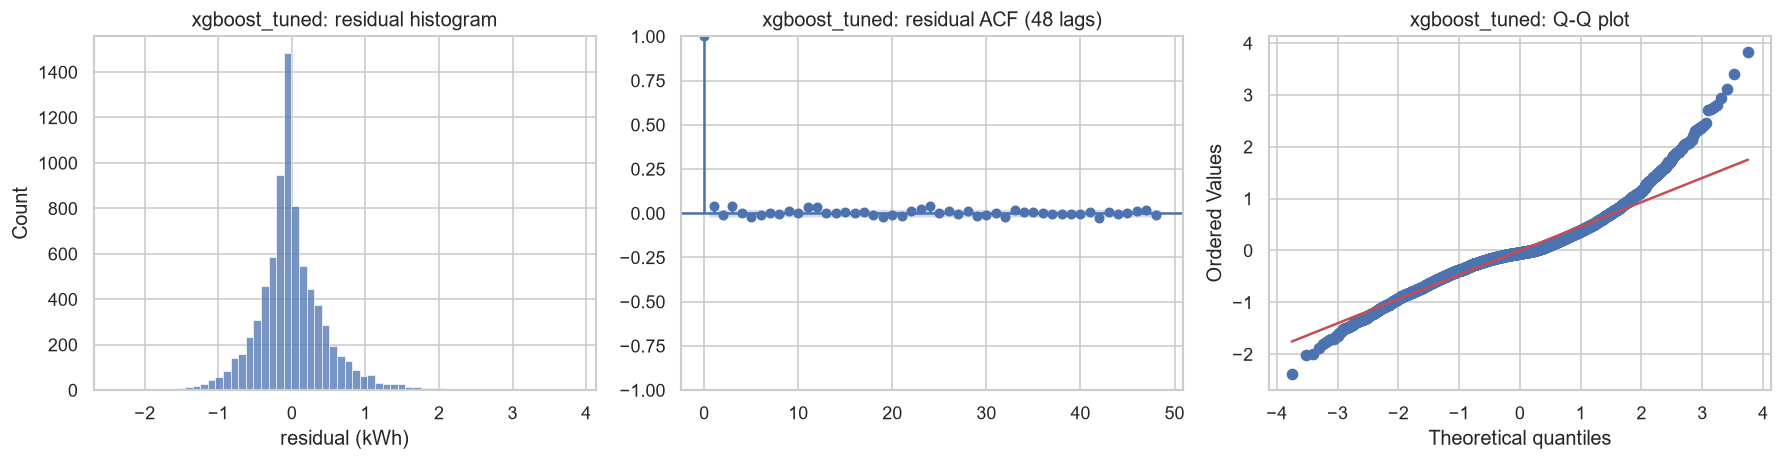

In [5]:
for name in ['xgboost_tuned','sarima','lstm']:
    evaluation.residual_diagnostics(name, preds[name])
Image(str(FIG / '02_residuals_xgboost_tuned.png'))

## Phase 15 - Error analysis

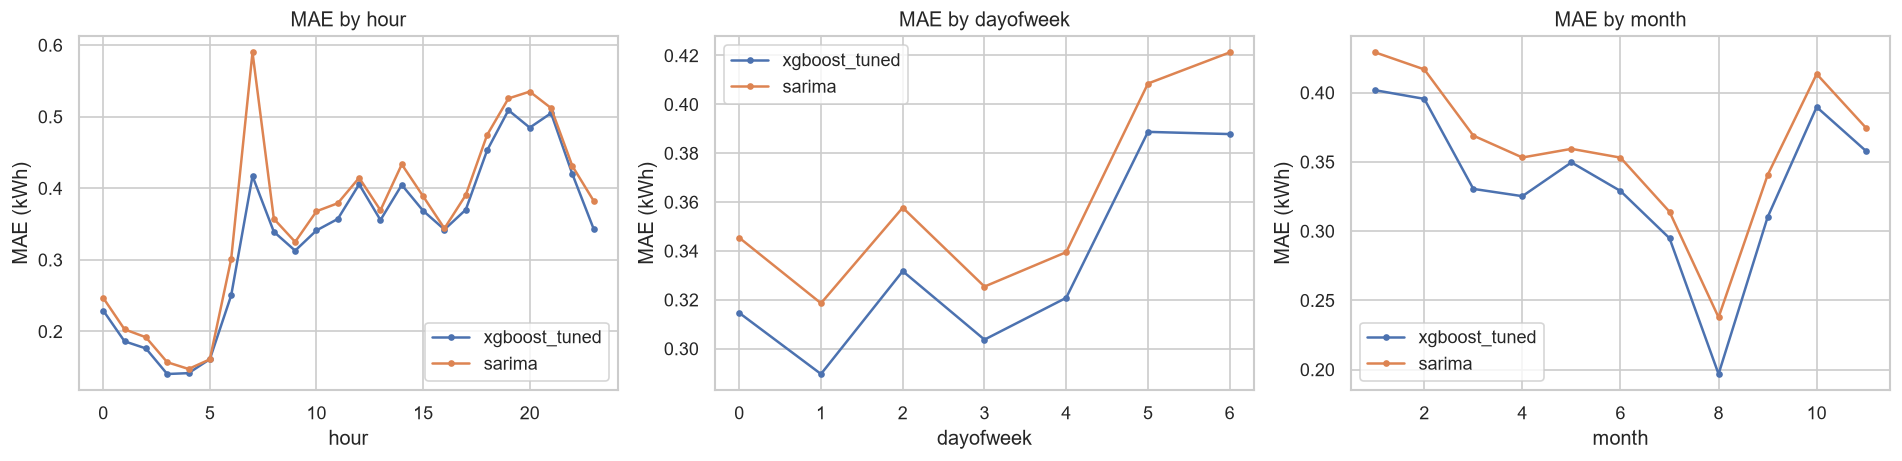

In [6]:
evaluation.plot_error_breakdowns(preds, ['xgboost_tuned','sarima'])
Image(str(FIG / '03_error_breakdowns.png'))

In [7]:
from xgboost import XGBRegressor
winner = XGBRegressor(random_state=42, n_jobs=-1, **modeling.TUNED_XGB_PARAMS)
winner.fit(matrix.X_train, matrix.y_train)
importances = pd.Series(winner.feature_importances_, index=matrix.features).sort_values(ascending=False)
evaluation.plot_feature_importances(importances)
importances.head(10).round(4)

lag_1           0.3981
lag_168         0.0811
hour            0.0565
lag_336         0.0532
hour_cos        0.0531
hour_sin        0.0411
roll_mean_24    0.0314
roll_std_24     0.0307
lag_24          0.0286
is_weekend      0.0249
dtype: float32

In [8]:
hour_mae = pd.DataFrame({m: evaluation.mae_by(preds[m], 'hour') for m in ['xgboost_tuned','sarima']})
print('Worst hours (MAE):')
print(hour_mae.round(3).sort_values('xgboost_tuned', ascending=False).head(4).to_string())
month_mae = pd.DataFrame({m: evaluation.mae_by(preds[m], 'month') for m in ['xgboost_tuned','sarima']})
print('\nBest/worst months (MAE):')
print(month_mae.round(3).loc[[8, 1]].to_string())

Worst hours (MAE):
           xgboost_tuned  sarima
timestamp                       
19                 0.509   0.525
21                 0.505   0.512
20                 0.485   0.535
18                 0.453   0.474

Best/worst months (MAE):
           xgboost_tuned  sarima
timestamp                       
8                  0.197   0.238
1                  0.402   0.429


## Phase 16 - Hypotheses (recomputed statistics)

In [9]:
series = pd.read_parquet(ROOT / 'data/processed/household_power_hourly.parquet')['Global_active_power']
kw_dow = stats_tests.kruskal_by(series, 'day_of_week')
kw_hour = stats_tests.kruskal_by(series, 'hour')
print(f'H1 Kruskal-Wallis day-of-week: H={kw_dow.statistic:.1f} p={kw_dow.pvalue:.2e} significant={kw_dow.significant}')
print(f'   Kruskal-Wallis hour       : H={kw_hour.statistic:.1f} p={kw_hour.pvalue:.2e}')

H1 Kruskal-Wallis day-of-week: H=239.3 p=0.00e+00 significant=True
   Kruskal-Wallis hour       : H=8842.5 p=0.00e+00


In [10]:
stat = stats_tests.stationarity_raw_and_differenced(series)
for k, r in stat.items():
    print(f'H2 [{r.label}] ADF p={r.adf_pvalue:.2e} | KPSS p={r.kpss_pvalue:.3f} | {r.verdict}')

C:\Claude\Projects\time_series_forecasting_project\src\stats_tests.py:60: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pvalue, *_ = kpss(series, regression="c", nlags="auto")


H2 [raw] ADF p=9.56e-27 | KPSS p=0.010 | inconclusive
H2 [seasonal_diff_24] ADF p=0.00e+00 | KPSS p=0.100 | stationary


C:\Claude\Projects\time_series_forecasting_project\src\stats_tests.py:60: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pvalue, *_ = kpss(series, regression="c", nlags="auto")


### Hypothesis verdicts

- **H1 (weekly seasonality) - SUPPORTED.** Kruskal-Wallis on day-of-week is highly significant (H = 239.3, p < 1e-40); the daily factor is far stronger (H = 8842.5).
- **H2 (non-stationary raw, stationary after seasonal differencing) - SUPPORTED.** The raw series is not cleanly stationary (ADF rejects a unit root, p ~ 1e-26, but KPSS rejects stationarity, p <= 0.01). The lag-24 seasonal difference is stationary under both tests (ADF p ~ 0, KPSS p >= 0.10).
- **H3 (tree >= LSTM) - SUPPORTED.** XGBoost beats the LSTM in cross-validation (CV MAE 0.378 vs 0.415) and on the test set (0.334 vs 0.371), at a fraction of the compute (~3 s to fit vs ~340 s for the LSTM).

### Business questions

- **Q1 - Can we forecast next-hour and next-day demand?** Yes. Next-hour tuned XGBoost: MAE 0.334 kWh, MASE 0.510. Next-day (direct h=24) XGBoost: MAE 0.444 kWh, MASE 0.678. Both beat their seasonal-naive baseline (MASE < 1).
- **Q2 - Dominant temporal patterns?** A dominant daily cycle (Kruskal hour H = 8843), a significant weekly cycle separating weekday from weekend routines (H = 239), and an annual seasonal component with a winter demand peak (monthly MAE and STL from Block A). Autocorrelation stays significant out to 720 lags.
- **Q3 - Best paradigm vs complexity?** XGBoost leads on both accuracy (lowest MAE) and cost (seconds to fit, no scaling, CPU-friendly). SARIMA is a close second but needs a windowed refit per fold; the LSTM is the most expensive and the weakest of the three, so the accuracy-per-unit-complexity winner is the gradient-boosted tree.

### Insights and limitations

**Insights.** Recent demand (`lag_1`, importance 0.40) and the weekly lag (`lag_168`) carry most of the signal; errors concentrate in the evening peak (19-21h) and the morning ramp (07h, where SARIMA is notably weaker), on weekends, and in winter months. August is the easiest month (MAE 0.20, low holiday-season demand).

**Limitations.** SARIMA was trained on a reduced recent window (~90 days) for tractability; the LSTM cross-validation used 3 folds (not fully comparable to the 5-fold models); the series is a single household; no weather or other exogenous regressors were used; and the next-day forecast comes from a direct h=24 model only (no recursive or multi-output alternative was compared).